<div dir="rtl">

# تعریف مسئله و متغیر هدف

در این بخش، هدف اصلی مشخص کردن دقیق مسئله‌ی پیش‌بینی است. از آن‌جا که مجموعه‌داده شامل آگهی‌های مختلف فروش، رهن و اجاره است، لازم است پیش از آموزش مدل تعیین شود که مدل قرار است دقیقاً چه مقدار مالی‌ای را پیش‌بینی کند.

برای این منظور، ابتدا انواع معامله‌های موجود در داده بررسی می‌شوند و سپس برای هر نوع معامله، ستون مناسب به‌عنوان متغیر هدف (`Target`) انتخاب خواهد شد.

مواردی که در این مرحله بررسی می‌شوند شامل موارد زیر هستند:

1. تعیین نوع مسئله‌ی پیش‌بینی برای آگهی‌های فروش و اجاره.
2. مشخص کردن ستون مناسب قیمت برای آگهی‌های فروش.
3. مشخص کردن مقدار مالی مناسب برای آگهی‌های رهن و اجاره.
4. بررسی امکان استفاده از یک مدل مشترک یا مدل‌های جداگانه برای انواع معامله.
5. بررسی تعداد داده‌های دارای Target معتبر برای هر گروه.
6. مشخص کردن داده‌هایی که به دلیل نداشتن Target معتبر، قابل استفاده در مدل‌سازی نیستند.

هدف این مرحله، رسیدن به یک تعریف شفاف و قابل دفاع از متغیر هدف است تا در مراحل بعدی، انتخاب Featureها، تقسیم داده و آموزش مدل بر اساس همین تعریف انجام شود.

</div>

In [67]:
import pandas as pd
import numpy as np

In [68]:
df = pd.read_parquet("../data/Divar_cleaned.parquet")


In [69]:
valid_transaction_types = [
    "residential-sell",
    "commercial-sell",
    "residential-rent",
    "commercial-rent"
]

model_df = df[df["cat2_slug"].isin(valid_transaction_types)].copy()

print("Rows before filtering:", len(df))
print("Rows after filtering:", len(model_df))

print("\nSelected transaction types:")
print(model_df["cat2_slug"].value_counts())

Rows before filtering: 999997
Rows after filtering: 950691

Selected transaction types:
cat2_slug
residential-sell    558707
residential-rent    276558
commercial-rent      76565
commercial-sell      38861
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

### بررسی آگهی‌های اجاره کوتاه‌مدت

در این مرحله، آگهی‌های دسته‌ی `temporary-rent` به‌صورت جداگانه بررسی شدند تا مشخص شود آیا می‌توان برای آن‌ها نیز متغیر هدف مشترک `unified_price` را تعریف کرد یا خیر.

تعداد کل آگهی‌های اجاره کوتاه‌مدت برابر با **29,903** ردیف بود.

بررسی ستون‌های مالی نشان داد:

- تنها **5** ردیف دارای `price_value` بودند.
- تنها **3** ردیف دارای `credit_value` بودند.
- تنها **3** ردیف دارای `rent_value` بودند.
- ستون‌های `transformable_credit`، `transformed_credit`، `transformable_rent` و `transformed_rent` برای تمام این دسته فاقد مقدار بودند.
- ستون `rent_type` نیز تنها برای **2** ردیف مقدار داشت.
- `inferred_full_credit` نیز فقط برای **2** ردیف قابل تشخیص بود.

بنابراین تقریباً تمام آگهی‌های `temporary-rent` فاقد اطلاعات مالی لازم برای ساخت `unified_price` هستند.

در نتیجه، با وجود اینکه اجاره کوتاه‌مدت از نظر مفهومی جزو معاملات اجاره محسوب می‌شود، در این دیتاست امکان تعریف یک Target مالی قابل اتکا برای آن وجود ندارد. به همین دلیل، این دسته از داده‌های مورد استفاده برای مدل پیش‌بینی حذف می‌شود.

همچنین دسته‌ی `real-estate-services` نیز به دلیل اینکه مربوط به خدمات حوزه املاک است و نه معامله مستقیم یک ملک، وارد مدل نخواهد شد.

در نتیجه، انواع معامله‌ی مورد استفاده در مدل عبارت‌اند از:

- `residential-sell`
- `commercial-sell`
- `residential-rent`
- `commercial-rent`

</div>

In [70]:

is_sell = model_df["cat2_slug"].str.contains("sell", na=False)

is_full_credit = (
    (model_df["inferred_full_credit"] == True)
    .fillna(False)
)

conditions = [
    is_sell,
    is_full_credit
]

choices = [
    model_df["price_value"],
    model_df["transformable_credit"]
]

model_df["unified_price"] = np.select(
    conditions,
    choices,
    default=model_df["transformed_credit"]
)

# Zero cannot be used as a valid target
model_df["unified_price"] = model_df["unified_price"].replace(0, np.nan)

In [71]:
valid_target = model_df["unified_price"].notna()

print("Total modeling rows:", len(model_df))
print("Valid targets:", valid_target.sum())
print("Missing targets:", (~valid_target).sum())
print(
    "Target coverage:",
    round(valid_target.mean() * 100, 2),
    "%"
)

print("\nValid targets by transaction type:")
print(
    model_df.loc[valid_target, "cat2_slug"]
    .value_counts()
)

Total modeling rows: 950691
Valid targets: 680999
Missing targets: 269692
Target coverage: 71.63 %

Valid targets by transaction type:
cat2_slug
residential-sell    533260
residential-rent    104051
commercial-sell      31929
commercial-rent      11759
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

### تعریف نهایی مسئله و متغیر هدف

در این پروژه یک مدل رگرسیون مشترک برای پیش‌بینی ارزش مالی آگهی‌های املاک در نظر گرفته شد.

چهار نوع معامله در داده‌های مدل نگه داشته شدند:

- فروش مسکونی
- فروش تجاری
- اجاره مسکونی
- اجاره تجاری

دسته‌ی `real-estate-services` به دلیل مربوط بودن به خدمات املاک و دسته‌ی `temporary-rent` به دلیل نبود اطلاعات مالی کافی برای تعریف متغیر هدف، از داده‌های مدل حذف شدند.

متغیر هدف مدل با نام `unified_price` تعریف شد تا انواع مختلف معاملات دارای یک Target عددی مشترک باشند.

منطق ساخت متغیر هدف به شکل زیر است:

- در آگهی‌های فروش از `price_value` استفاده می‌شود.
- در آگهی‌های رهن کامل، که با `inferred_full_credit` تشخیص داده می‌شوند، از `transformable_credit` استفاده می‌شود.
- در سایر آگهی‌های اجاره از `transformed_credit` استفاده می‌شود.
- مقادیر صفر به‌عنوان Target معتبر در نظر گرفته نمی‌شوند.

همچنین نوع معامله (`cat2_slug`) در مراحل بعدی به‌عنوان یکی از ویژگی‌های ورودی مدل استفاده خواهد شد تا مدل بتواند تفاوت میان انواع معاملات را تشخیص دهد.

</div>

<div dir="rtl">

# تسک ۲ — ساخت دیتاست نهایی مدل و بررسی کیفیت Target

در این مرحله، متغیر هدف نهایی برای مدل ساخته و کیفیت آن بررسی می‌شود.

اهداف این بخش:

- بررسی Targetهای گمشده
- بازیابی Targetهایی که از اطلاعات مالی موجود قابل محاسبه هستند
- ساخت Target نهایی برای فروش و اجاره
- بررسی مقادیر غیرعادی و Outlierها
- ساخت دیتاست نهایی مخصوص مدل‌سازی
- حفظ داده‌های اصلی بدون تغییر

در این مرحله Outlierها شناسایی می‌شوند، اما برای جلوگیری از نشت اطلاعات، مرزهای نهایی Capping بعد از تقسیم Train / Validation / Test و فقط بر اساس Train محاسبه خواهند شد.

</div>

In [72]:
missing_target_df = model_df[
    model_df["unified_price"].isna()
].copy()

print("Total missing targets:", len(missing_target_df))

print("\nMissing targets by transaction type:")
print(missing_target_df["cat2_slug"].value_counts())

Total missing targets: 269692

Missing targets by transaction type:
cat2_slug
residential-rent    172507
commercial-rent      64806
residential-sell     25447
commercial-sell       6932
Name: count, dtype: int64[pyarrow]


In [73]:
check_cols = [
    "price_value",
    "credit_value",
    "rent_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
    "rent_type",
    "rent_credit_transform",
    "inferred_full_credit"
]

for category in missing_target_df["cat2_slug"].dropna().unique():

    subset = missing_target_df[
        missing_target_df["cat2_slug"] == category
    ]

    print("\n" + "=" * 70)
    print("Category:", category)
    print("Rows:", len(subset))

    for col in check_cols:
        print(
            f"{col:25s} -> "
            f"{subset[col].notna().sum():,} non-null"
        )


Category: residential-rent
Rows: 172507
price_value               -> 6 non-null
credit_value              -> 172,033 non-null
rent_value                -> 171,269 non-null
transformable_credit      -> 172,033 non-null
transformed_credit        -> 19 non-null
transformable_rent        -> 171,268 non-null
transformed_rent          -> 19 non-null
rent_type                 -> 48,438 non-null
rent_credit_transform     -> 172,483 non-null
inferred_full_credit      -> 47,254 non-null

Category: commercial-rent
Rows: 64806
price_value               -> 34 non-null
credit_value              -> 64,240 non-null
rent_value                -> 64,231 non-null
transformable_credit      -> 64,240 non-null
transformed_credit        -> 17 non-null
transformable_rent        -> 64,227 non-null
transformed_rent          -> 17 non-null
rent_type                 -> 14,687 non-null
rent_credit_transform     -> 64,691 non-null
inferred_full_credit      -> 14,248 non-null

Category: residential-sell
Rows: 25447


In [74]:
conversion_df = model_df[
    model_df["credit_value"].notna()
    & model_df["rent_value"].notna()
    & model_df["transformed_credit"].notna()
    & model_df["transformed_rent"].notna()
].copy()

denominator = (
    conversion_df["rent_value"]
    - conversion_df["transformed_rent"]
)

valid_conversion = denominator != 0

conversion_df = conversion_df.loc[
    valid_conversion
].copy()

conversion_df["conversion_rate"] = (
    (
        conversion_df["transformed_credit"]
        - conversion_df["credit_value"]
    )
    /
    (
        conversion_df["rent_value"]
        - conversion_df["transformed_rent"]
    )
)

valid_rates = conversion_df.loc[
    (conversion_df["conversion_rate"] > 0)
    & np.isfinite(conversion_df["conversion_rate"]),
    "conversion_rate"
]

conversion_rate = valid_rates.median()

print("Valid conversion rows:", len(valid_rates))
print("Median conversion rate:", conversion_rate)

Valid conversion rows: 72409
Median conversion rate: 33.333333333333336


In [75]:
model_ready_df = model_df.copy()

is_sell = model_ready_df["cat2_slug"].str.contains(
    "sell",
    na=False
)

is_rent = model_ready_df["cat2_slug"].str.contains(
    "rent",
    na=False
)

model_ready_df["unified_price_final"] = np.nan


# Sale
valid_sell = (
    is_sell
    & model_ready_df["price_value"].notna()
    & (model_ready_df["price_value"] > 0)
)

model_ready_df.loc[
    valid_sell,
    "unified_price_final"
] = model_ready_df.loc[
    valid_sell,
    "price_value"
]


# Rent / Full Credit
valid_rent = (
    is_rent
    & model_ready_df["credit_value"].notna()
    & model_ready_df["rent_value"].notna()
)

model_ready_df.loc[
    valid_rent,
    "unified_price_final"
] = (
    model_ready_df.loc[
        valid_rent,
        "credit_value"
    ]
    +
    model_ready_df.loc[
        valid_rent,
        "rent_value"
    ] * conversion_rate
)

In [76]:
valid_final_target = (
    model_ready_df["unified_price_final"].notna()
)

print("Total rows:", len(model_ready_df))

print(
    "Valid final targets:",
    valid_final_target.sum()
)

print(
    "Missing final targets:",
    (~valid_final_target).sum()
)

print(
    "Coverage:",
    round(valid_final_target.mean() * 100, 2),
    "%"
)

print("\nValid targets by transaction type:")

print(
    model_ready_df.loc[
        valid_final_target,
        "cat2_slug"
    ].value_counts()
)

Total rows: 950691
Valid final targets: 916369
Missing final targets: 34322
Coverage: 96.39 %

Valid targets by transaction type:
cat2_slug
residential-sell    533260
residential-rent    275264
commercial-rent      75916
commercial-sell      31929
Name: count, dtype: int64[pyarrow]


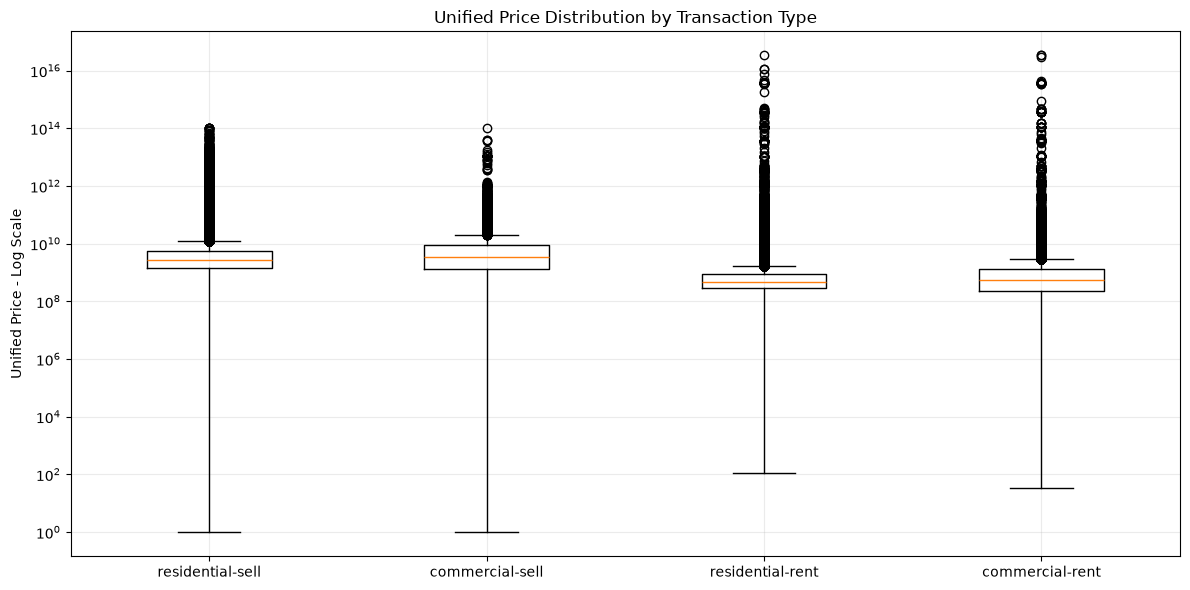

In [77]:
import matplotlib.pyplot as plt

box_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

category_order = [
    "residential-sell",
    "commercial-sell",
    "residential-rent",
    "commercial-rent"
]

data = []

for cat in category_order:

    values = pd.to_numeric(
        box_df.loc[
            box_df["cat2_slug"] == cat,
            "unified_price_final"
        ],
        errors="coerce"
    ).dropna().astype(float).to_numpy()

    data.append(values)

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    tick_labels=category_order,
    showfliers=True
)

plt.yscale("log")

plt.title(
    "Unified Price Distribution by Transaction Type"
)

plt.ylabel(
    "Unified Price - Log Scale"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [78]:
outlier_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

outlier_df["log_target"] = np.log1p(
    outlier_df["unified_price_final"]
)

outlier_df["extreme_outlier"] = False

for cat in outlier_df["cat2_slug"].unique():

    mask = outlier_df["cat2_slug"] == cat

    values = outlier_df.loc[
        mask,
        "log_target"
    ]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr

    outlier_df.loc[
        mask
        & (
            (outlier_df["log_target"] < lower)
            | (outlier_df["log_target"] > upper)
        ),
        "extreme_outlier"
    ] = True


print(
    "Total valid targets:",
    len(outlier_df)
)

print(
    "Extreme outliers:",
    outlier_df["extreme_outlier"].sum()
)

print(
    "\nExtreme outliers by category:"
)

print(
    outlier_df.loc[
        outlier_df["extreme_outlier"],
        "cat2_slug"
    ].value_counts()
)

KeyboardInterrupt: 

In [ ]:
model_ready_df["extreme_outlier"] = False

model_ready_df.loc[
    outlier_df.index,
    "extreme_outlier"
] = outlier_df["extreme_outlier"]

print(
    "Extreme outliers:",
    model_ready_df["extreme_outlier"].sum()
)

Extreme outliers: 16600


In [ ]:
before = len(model_ready_df)

model_ready_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

removed = before - len(model_ready_df)

print(
    "Rows before target cleaning:",
    before
)

print(
    "Final modeling rows:",
    len(model_ready_df)
)

print(
    "Removed missing targets:",
    removed
)

print(
    "Missing targets:",
    model_ready_df[
        "unified_price_final"
    ].isna().sum()
)

print(
    "Extreme outliers flagged:",
    model_ready_df[
        "extreme_outlier"
    ].sum()
)

print(
    "\nFinal rows by transaction type:"
)

print(
    model_ready_df[
        "cat2_slug"
    ].value_counts()
)

Rows before target cleaning: 950691
Final modeling rows: 916369
Removed missing targets: 34322
Missing targets: 0
Extreme outliers flagged: 16600

Final rows by transaction type:
cat2_slug
residential-sell    533260
residential-rent    275264
commercial-rent      75916
commercial-sell      31929
Name: count, dtype: int64[pyarrow]


In [ ]:
# Rule-based target validation

target = pd.to_numeric(
    model_ready_df["unified_price_final"],
    errors="coerce"
)

is_sell = model_ready_df["cat2_slug"].str.contains(
    "sell",
    na=False
)

# Sale prices below 100 million
low_sale_price = (
    is_sell
    & target.notna()
    & (target < 100_000_000)
)

# Convert explicitly to Python string
# because PyArrow regex does not support backreferences such as \1
target_string = (
    target.round()
    .astype("Int64")
    .astype("string[python]")
)

# Suspicious repeated-digit prices:
# 9999999, 1111111111, 777777777, ...
repeated_digit_price = (
    is_sell
    & target_string.str.fullmatch(
        r"([1-9])\1{6,}",
        na=False
    )
)

rule_based_invalid_target = (
    low_sale_price
    | repeated_digit_price
)

print(
    "Sale prices below 100M:",
    low_sale_price.sum()
)

print(
    "Repeated-digit suspicious prices:",
    repeated_digit_price.sum()
)

print(
    "Total rule-based invalid targets:",
    rule_based_invalid_target.sum()
)

display(
    model_ready_df.loc[
        rule_based_invalid_target,
        [
            "cat2_slug",
            "unified_price_final"
        ]
    ].head(20)
)

Sale prices below 100M: 14961
Repeated-digit suspicious prices: 10618
Total rule-based invalid targets: 23110


,cat2_slug,unified_price_final
56,commercial-sell,1.000000e+02
69,residential-sell,1.111111e+08
93,residential-sell,2.730000e+06
129,residential-sell,1.111111e+09
242,residential-sell,1.111112e+06
262,commercial-sell,1.000000e+00
280,residential-sell,1.111111e+08
305,residential-sell,1.110000e+02
329,residential-sell,1.111111e+10
367,residential-sell,1.234500e+04


In [ ]:
before = len(model_ready_df)

invalid_target_df = model_ready_df.loc[
    rule_based_invalid_target
].copy()

model_ready_df = model_ready_df.loc[
    ~rule_based_invalid_target
].copy()

print("Rows before rule-based validation:", before)

print(
    "Removed invalid targets:",
    len(invalid_target_df)
)

print(
    "Final modeling rows:",
    len(model_ready_df)
)

print(
    "\nFinal rows by transaction type:"
)

print(
    model_ready_df["cat2_slug"].value_counts()
)

Rows before rule-based validation: 916369
Removed invalid targets: 23110
Final modeling rows: 893259

Final rows by transaction type:
cat2_slug
residential-sell    512944
residential-rent    275264
commercial-rent      75916
commercial-sell      29135
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

# جمع‌بندی نهایی تسک ۲ — ساخت و اعتبارسنجی متغیر هدف

هدف این مرحله، ساخت یک متغیر هدف عددی، قابل مقایسه و قابل استفاده برای آموزش مدل رگرسیون بود؛ به‌گونه‌ای که تفاوت ساختاری میان معاملات فروش، رهن کامل و رهن‌واجاره باعث از دست رفتن بخش بزرگی از داده‌ها نشود.

---

## ۱. مشکل تعریف اولیه‌ی Target

در تعریف اولیه، برای فروش از `price_value` و برای بخش اجاره عمدتاً از ستون‌های تبدیل‌شده مانند `transformed_credit` استفاده شده بود.

این تعریف باعث شد از مجموع **950,691** رکورد انتخاب‌شده، تنها **680,999** رکورد دارای Target معتبر باشند و پوشش Target برابر با **71.63٪** شود.

بررسی دقیق‌تر نشان داد بخش قابل توجهی از Missing Targetها واقعاً فاقد اطلاعات مالی نبودند. برای مثال، تعداد زیادی از آگهی‌های اجاره دارای مقادیر معتبر `credit_value` و `rent_value` بودند، اما چون ستون `transformed_credit` تنها در بخشی از داده‌ها مقدار داشت، Target آن‌ها به اشتباه Missing شده بود.

بنابراین Missing بودن `transformed_credit` لزوماً به معنای نبود اطلاعات مالی قابل استفاده نبود.

---

## ۲. تعریف Target برای آگهی‌های فروش

برای معاملات فروش، متغیر هدف مستقیماً از:

`price_value`

گرفته شد.

این انتخاب مستقیم‌ترین تعریف ممکن است، زیرا `price_value` مبلغ اعلام‌شده برای فروش ملک است و نیاز به تبدیل مالی دیگری ندارد.

مقادیر صفر یا Missing به‌عنوان Target معتبر در نظر گرفته نشدند.

---

## ۳. یکپارچه‌سازی رهن و اجاره

آگهی‌های اجاره معمولاً دارای دو جزء مالی هستند:

- مبلغ رهن یا ودیعه (`credit_value`)
- مبلغ اجاره (`rent_value`)

از آن‌جا که مدل باید یک خروجی عددی واحد داشته باشد، برای معاملات اجاره یک **ارزش معادل رهن** تعریف شد:

`Equivalent Credit = credit_value + rent_value × conversion_rate`

در نتیجه، تمام حالت‌های اجاره روی یک مقیاس مالی مشترک قرار گرفتند.

این رابطه رهن کامل را نیز به‌طور طبیعی پوشش می‌دهد، زیرا در رهن کامل:

`rent_value = 0`

و در نتیجه:

`Equivalent Credit = credit_value`

---

## ۴. استخراج نرخ تبدیل از خود دیتاست

به‌جای استفاده از یک نرخ قراردادی ثابت، نرخ تبدیل با استفاده از رکوردهایی محاسبه شد که مقادیر اولیه و تبدیل‌شده‌ی رهن و اجاره را هم‌زمان داشتند.

نرخ تبدیل با استفاده از:

`credit_value`

`rent_value`

`transformed_credit`

`transformed_rent`

استخراج شد.

سپس **Median** نرخ‌های معتبر به‌عنوان نرخ تبدیل نهایی استفاده شد.

Median نسبت به Mean در برابر داده‌های پرت و توزیع‌های دارای چولگی مقاوم‌تر است و به همین دلیل برای این مسئله انتخاب مناسب‌تری محسوب می‌شود.

---

## ۵. تعریف Target نهایی

Target نهایی با نام:

`unified_price_final`

تعریف شد.

منطق آن:

**فروش**

`unified_price_final = price_value`

**رهن و اجاره**

`unified_price_final = credit_value + rent_value × conversion_rate`

نوع معامله نیز از طریق Featureهایی مانند `cat2_slug` برای مدل قابل تشخیص باقی می‌ماند.

---

## ۶. بازیابی Missing Targetها

پس از بازتعریف Target:

- تعداد کل رکوردها: **950,691**
- Target معتبر: **916,369**
- Target غیرقابل بازیابی: **34,322**
- پوشش Target: **96.39٪**

بنابراین پوشش Target از:

**71.63٪ → 96.39٪**

افزایش یافت.

این افزایش بدون Imputation مصنوعی Target انجام شد و تنها از اطلاعات مالی واقعی موجود در همان رکورد استفاده شد.

این موضوع اهمیت دارد، زیرا تخمین مصنوعی Target با Mean، Median، KNN یا یک مدل دیگر می‌تواند باعث ایجاد **Label Noise** و تحریف رابطه واقعی میان Featureها و Target شود.

---

## ۷. چرا Targetهای باقی‌مانده Impute نشدند؟

برای **34,322** رکورد اطلاعات کافی برای ساخت یک Target قابل دفاع وجود نداشت.

از آن‌جا که Target همان متغیری است که مدل باید یاد بگیرد، ساختن مقدار مصنوعی برای آن می‌تواند:

- Label Noise ایجاد کند
- رابطه Featureها و Target را تغییر دهد
- ارزیابی مدل را بیش از حد خوش‌بینانه کند
- مدل را روی مقادیر غیرواقعی آموزش دهد

بنابراین این رکوردها از دیتاست مدل‌سازی کنار گذاشته شدند، در حالی که دیتای اصلی بدون تغییر باقی ماند.

---

## ۸. بررسی آماری Outlierها

توزیع `unified_price_final` با Box Plot و آمار توصیفی بررسی شد.

از آن‌جا که قیمت املاک معمولاً دارای توزیع راست‌چوله و دنباله‌ی بلند است، صرفاً بزرگ یا کوچک بودن یک قیمت دلیل کافی برای حذف آن نیست.

ابتدا تبدیل لگاریتمی اعمال شد:

`log_target = log(1 + unified_price_final)`

سپس Extreme Outlierها برای هر نوع معامله به‌صورت جداگانه با معیار محافظه‌کارانه‌ی زیر شناسایی شدند:

`Q1 - 3 × IQR`

`Q3 + 3 × IQR`

استفاده از **3×IQR** به‌جای 1.5×IQR باعث می‌شود فقط نقاط بسیار دورافتاده علامت‌گذاری شوند و املاک گران یا ارزان ولی واقعی تا حد ممکن حفظ شوند.

---

## ۹. نتیجه‌ی بررسی آماری Outlierها

از مجموع **916,369** Target معتبر:

- **16,600** رکورد به‌عنوان Extreme Outlier شناسایی شدند
- این مقدار حدود **1.81٪** داده‌های معتبر بود

این رکوردها در این مرحله مستقیماً حذف نشدند و با Feature:

`extreme_outlier`

علامت‌گذاری شدند.

دلیل این تصمیم این است که **Outlier آماری الزاماً به معنی داده اشتباه نیست**.

---

## ۱۰. اعتبارسنجی Rule-Based برای Targetهای مشکوک

بررسی بیشتر نشان داد روش آماری `3×IQR` به‌تنهایی نمی‌تواند همه‌ی Targetهای غیرقابل اعتماد را تشخیص دهد.

برای مثال، مقادیری با الگوهایی مانند:

`9999999`

`1111111111`

یا سایر اعداد تکراری ممکن است از نظر توزیع آماری داخل محدوده طبیعی قرار بگیرند، اما از نظر کیفیت داده احتمال زیادی وجود دارد که مقدار واقعی قیمت نباشند و به‌عنوان مقدار موقت یا ساختگی ثبت شده باشند.

همچنین قیمت‌های فروش بسیار پایین، از جمله مقادیر کمتر از **100 میلیون**، به‌عنوان یک Rule جداگانه بررسی شدند؛ زیرا در این دیتاست چنین مقادیری نسبت به دامنه معمول قیمت فروش بسیار مشکوک هستند.

بنابراین علاوه بر تشخیص آماری Outlier، یک مرحله‌ی **Rule-Based Target Validation** نیز انجام شد.

دو Rule اصلی عبارت بودند از:

- شناسایی قیمت‌های فروش کمتر از `100,000,000`
- شناسایی قیمت‌هایی با الگوی تکرار یک رقم، مانند `111111111` یا `999999999`

این مرحله مکمل روش IQR است:

- `IQR` ناهنجاری‌های **آماری** را پیدا می‌کند
- Rule-Based Validation ناهنجاری‌های **معنایی و مرتبط با کیفیت داده** را پیدا می‌کند

بنابراین ترکیب این دو روش باعث می‌شود Targetهای غیرقابل اعتماد بهتر شناسایی شوند.

> تعداد نهایی رکوردهای حذف‌شده در این مرحله بر اساس خروجی واقعی Rule-Based Validation ثبت می‌شود.

---

## ۱۱. چرا Capping نهایی در این مرحله انجام نشد؟

برای جلوگیری از **Data Leakage**، مرزهای نهایی Capping نباید با استفاده از کل دیتاست محاسبه شوند.

اگر Test Data در محاسبه Quantile، IQR یا مرزهای Capping نقش داشته باشد، بخشی از اطلاعات توزیع Test پیش از آموزش وارد فرآیند مدل‌سازی می‌شود.

بنابراین مرزهای نهایی Capping پس از:

`Train / Validation / Test Split`

و تنها با استفاده از **Train Set** محاسبه خواهند شد.

همان مرزهای محاسبه‌شده از Train بدون Fit مجدد روی Validation و Test اعمال خواهند شد.

---

# خروجی نهایی تسک ۲

دیتاست اصلی آماده‌شده برای مراحل بعدی:

`model_ready_df`

متغیر هدف:

`unified_price_final`

قبل از Rule-Based Validation:

- Target معتبر: **916,369**
- Target غیرقابل بازیابی: **34,322**
- Coverage: **96.39٪**

Extreme Outlierهای آماری:

- **16,600**
- حدود **1.81٪**

Feature مربوط به Outlier آماری:

`extreme_outlier`

علاوه بر Outlier Detection آماری، Targetهای مشکوک با قواعد مبتنی بر کیفیت داده نیز بررسی شدند تا مقادیری که از نظر آماری Outlier نیستند اما از نظر معنایی غیرقابل اعتماد هستند، وارد آموزش مدل نشوند.

---

## نتیجه‌گیری

در این مرحله ابتدا Target فروش و اجاره روی یک ساختار عددی مشترک تعریف شد و پوشش Target از **71.63٪ به 96.39٪** افزایش یافت.

بیش از **235 هزار رکورد** بدون ساخت Label مصنوعی بازیابی شدند.

سپس کیفیت Target از دو دیدگاه بررسی شد:

1. **Statistical Validation** با Log Transformation و `3×IQR`
2. **Rule-Based Validation** برای شناسایی قیمت‌های غیرواقعی یا الگوهای مشکوک که لزوماً توسط IQR تشخیص داده نمی‌شوند

این ترکیب باعث می‌شود داده‌ی آموزشی علاوه بر پوشش بالا، از نظر کیفیت Target نیز قابل اعتمادتر باشد.

Capping نهایی نیز به بعد از Split منتقل شد تا پارامترهای آن فقط از Train استخراج شوند و از Data Leakage جلوگیری شود.

**✅ Task 2 Completed**

</div>

<div dir="rtl">

# تسک ۳ — بررسی Target Leakage

در این مرحله بررسی می‌کنیم که هیچ‌یک از Featureهای ورودی مدل، اطلاعاتی را مستقیماً یا غیرمستقیم از Target نهایی یعنی `unified_price_final` در اختیار مدل قرار ندهند.

از آن‌جا که `unified_price_final` با استفاده از ستون‌های مالی ساخته شده، ستون‌هایی مانند:

`price_value`، `credit_value`، `rent_value`،  
`transformable_credit`، `transformed_credit`،  
`transformable_rent` و `transformed_rent`

نباید به‌عنوان Feature وارد مدل شوند؛ زیرا مدل در این صورت به بخشی از اطلاعاتی دسترسی خواهد داشت که خود Target از آن‌ها ساخته شده است.

این وضعیت باعث **Target Leakage** می‌شود و می‌تواند عملکرد مدل را به‌صورت مصنوعی بهتر از حالت واقعی نشان دهد.

همچنین Featureهای مشتق‌شده از اطلاعات مالی، مانند `inferred_full_credit`، باید جداگانه بررسی شوند تا مشخص شود آیا استفاده از آن‌ها اطلاعاتی از Target را لو می‌دهد یا خیر.

هدف این مرحله:

- شناسایی Featureهای دارای Leakage
- حذف Featureهای مالی مستقیم یا مشتق‌شده از Target
- مشخص کردن لیست Featureهای مجاز برای مراحل بعدی مدل‌سازی

</div>

In [ ]:
# Columns that directly or indirectly reveal the target

leakage_cols = [
    # Original financial values
    "price_value",
    "credit_value",
    "rent_value",

    # Financial modes / transaction-related financial information
    "price_mode",
    "credit_mode",
    "rent_mode",
    "rent_type",
    "rent_credit_transform",

    # Derived financial columns
    "transformable_price",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",

    # Derived from rent/credit values
    "inferred_full_credit",

    # Targets / helper targets
    "unified_price",
    "unified_price_final",
    "unified_price_capped",

    # Outlier helper columns
    "log_target",
    "extreme_outlier"
]

# Only remove columns that actually exist
leakage_cols_existing = [
    col for col in leakage_cols
    if col in model_ready_df.columns
]

X = model_ready_df.drop(
    columns=leakage_cols_existing
).copy()

y = model_ready_df["unified_price_final"].copy()

print("Removed leakage columns:")
print(leakage_cols_existing)

print("\nNumber of remaining candidate features:", X.shape[1])
print("Number of samples:", len(X))

Removed leakage columns:
['price_value', 'credit_value', 'rent_value', 'price_mode', 'credit_mode', 'rent_mode', 'rent_type', 'rent_credit_transform', 'transformable_price', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'inferred_full_credit', 'unified_price', 'unified_price_final', 'extreme_outlier']

Number of remaining candidate features: 66
Number of samples: 893259


In [ ]:
remaining_leakage = [
    col for col in leakage_cols_existing
    if col in X.columns
]

print("Remaining leakage columns:", remaining_leakage)

assert len(remaining_leakage) == 0

print("\nTarget Leakage Check: PASSED")
print("X shape:", X.shape)
print("y shape:", y.shape)

Remaining leakage columns: []

Target Leakage Check: PASSED
X shape: (893259, 66)
y shape: (893259,)


<div dir="rtl">

## جمع‌بندی تسک ۳ — بررسی Target Leakage

در این مرحله ستون‌هایی که می‌توانستند اطلاعات Target نهایی یعنی `unified_price_final` را مستقیماً یا غیرمستقیم در اختیار مدل قرار دهند، شناسایی و از Featureهای ورودی حذف شدند.

مهم‌ترین ستون‌های حذف‌شده شامل مقادیر مالی اصلی و مشتق‌شده مانند:

`price_value`، `credit_value`، `rent_value`،  
`transformable_credit`، `transformed_credit`،  
`transformable_rent`، `transformed_rent`  
و سایر ستون‌های ساخته‌شده از اطلاعات مالی بودند.

دلیل علمی این کار جلوگیری از **Target Leakage** است. در صورت وجود Leakage، مدل بخشی از پاسخ صحیح را در ورودی دریافت می‌کند و عملکرد آن به‌صورت مصنوعی بهتر از واقعیت دیده می‌شود، در حالی که در شرایط واقعی چنین اطلاعاتی در زمان پیش‌بینی در دسترس نیست.

پس از حذف این ستون‌ها، بررسی نهایی نشان داد:

`Remaining leakage columns: []`

و تست مربوط به Leakage با موفقیت عبور کرد:

`Target Leakage Check: PASSED`

بنابراین در پایان این مرحله، `X` فقط شامل Featureهای کاندید ورودی و `y` برابر با `unified_price_final` است.

**✅ Task 3 Completed**

</div>

<div dir="rtl">

## تسک ۴ — بررسی Featureها و مدیریت Missing Valueها

هدف این مرحله این است که دیتای ورودی مدل از نظر کیفیت Featureها آماده شود.

کارهایی که باید انجام شوند:

1. بررسی تمام Featureهای باقی‌مانده بعد از حذف Leakage
2. محاسبه تعداد و درصد Missing Value برای هر Feature
3. جدا کردن Featureهای عددی و دسته‌ای
4. بررسی ستون‌هایی که Missing بسیار زیادی دارند
5. تصمیم‌گیری برای هر Feature دارای Missing:
   - پر کردن با Median برای Featureهای عددی، در صورت منطقی بودن
   - استفاده از مقدار `Unknown` برای Featureهای دسته‌ای، در صورت معنادار بودن Missing
   - حذف Featureهایی که اطلاعات بسیار کمی دارند یا درصد Missing آن‌ها بیش از حد زیاد است
   - عدم پر کردن مصنوعی در مواردی که Missing خودش معنی خاصی دارد
6. بررسی تعداد مقادیر یکتا برای شناسایی Featureهای کم‌اطلاعات یا تقریباً ثابت
7. مشخص کردن Featureهای نهایی برای مدل
8. ثبت دلیل علمی برای هر تصمیم مربوط به حذف یا Imputation

### نکته مهم

مقادیر آماری مورد استفاده برای Imputation، مثل Median، نباید از کل دیتاست محاسبه شوند.

پس از تقسیم داده به Train / Validation / Test، مقدار Median یا سایر پارامترهای Imputation فقط از Train محاسبه شده و همان مقدار روی Validation و Test اعمال می‌شود تا Data Leakage ایجاد نشود.

### خروجی نهایی مورد انتظار

- لیست Featureهای نهایی
- لیست Featureهای حذف‌شده همراه با دلیل
- روش مدیریت Missing Value هر Feature
- آماده شدن داده برای مرحله Train / Validation / Test Split
</div>

In [ ]:
pd.set_option("display.max_rows", 100)

profile = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "missing_%": (X.isna().mean() * 100).round(2),
    "unique": X.nunique(),
}).sort_values("missing_%", ascending=False)

print(f"tedad sotoon ha: {X.shape[1]} | tedad radif: {len(X):,}")
profile

tedad sotoon ha: 66 | tedad radif: 893,259


,dtype,missing,missing_%,unique
rent_price_at_weekends,float64,893259,100.00,0
rent_price_on_special_days,float64,893259,100.00,0
rent_price_on_regular_days,float64,893259,100.00,0
cost_per_extra_person,float64,893259,100.00,0
extra_person_capacity,Int64,893259,100.00,0
regular_person_capacity,Int64,893259,100.00,0
has_sauna,boolean,870066,97.40,2
has_jacuzzi,boolean,869867,97.38,2
has_pool,boolean,869307,97.32,2
has_barbecue,boolean,867600,97.13,2


In [ ]:
bool_cols = ["has_water", "has_electricity", "has_gas", "has_pool", "has_sauna",
             "has_jacuzzi", "has_barbecue", "has_security_guard", "has_business_deed",
             "has_elevator", "has_balcony", "has_parking", "has_warehouse", "is_rebuilt"]

bool_check = pd.DataFrame({
    "answered": X[bool_cols].notna().sum(),
    "true_%_of_answered": (X[bool_cols].sum() / X[bool_cols].notna().sum() * 100).round(1),
})
display(bool_check)

text_cols = ["title_length", "title_word_count", "description_length", "description_word_count"]
display(X[text_cols].astype(float).corr().round(3))

display(pd.crosstab(X["coord_status"], X["location_utm_x"].isna(), margins=True))

,answered,true_%_of_answered
has_water,27806,47.4
has_electricity,27801,47.1
has_gas,27796,46.7
has_pool,23952,10.9
has_sauna,23193,4.4
has_jacuzzi,23392,6.7
has_barbecue,25659,23.0
has_security_guard,25965,22.4
has_business_deed,25747,50.4
has_elevator,531284,67.4


,title_length,title_word_count,description_length,description_word_count
title_length,1.000,0.741,0.343,0.334
title_word_count,0.741,1.000,0.158,0.195
description_length,0.343,0.158,1.000,0.976
description_word_count,0.334,0.195,0.976,1.000


location_utm_x,False,True,All
coord_status,,,
door_az_shahr,0,7236,7236
kharej,0,35,35
missing,0,302248,302248
ok,574970,0,574970
pin_chand_shahri,0,8770,8770
All,574970,318289,893259


In [ ]:
luxury_cols = ["has_pool", "has_sauna", "has_jacuzzi", "has_barbecue", "has_security_guard"]
utility_cols = ["has_water", "has_electricity", "has_gas"]
three_state_cols = ["has_elevator", "has_balcony", "has_parking", "has_warehouse", "is_rebuilt", "has_business_deed"]
system_cols = ["has_heating_system", "has_cooling_system", "has_warm_water_provider", "has_restroom"]

X_feat = X.copy()

X_feat["luxury_asked"] = X_feat[luxury_cols].notna().any(axis=1)
X_feat["luxury_count"] = X_feat[luxury_cols].fillna(False).astype(int).sum(axis=1)

X_feat["utility_asked"] = X_feat[utility_cols].notna().any(axis=1)
X_feat["utility_count"] = X_feat[utility_cols].fillna(False).astype(int).sum(axis=1)

for col in three_state_cols:
    X_feat[col] = X_feat[col].map({True: "yes", False: "no"}).fillna("not_asked")

for col in system_cols:
    X_feat[col] = X_feat[col].fillna("unknown")

drop_cols = [
    "rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
    "cost_per_extra_person", "regular_person_capacity", "extra_person_capacity",
    "rent_price_on_regular_days_suspicious_low", "rent_price_on_special_days_suspicious_low",
    "rent_price_at_weekends_suspicious_low", "cost_per_extra_person_suspicious_low",
    "transformed_credit_suspicious_low", "transformed_rent_suspicious_low",
    "title", "description",
    "location_latitude", "location_longitude",
    "created_year", "created_month", "jalali_year", "jalali_label", "is_main_period",
    "description_word_count",
] + luxury_cols + utility_cols

X_feat = X_feat.drop(columns=drop_cols)

print(f"qabl: {X.shape[1]} sotoon | baad: {X_feat.shape[1]} sotoon")
print(f"hazf shode: {len(drop_cols)} | jadid: 4")
X_feat.dtypes.astype(str).value_counts()

qabl: 66 sotoon | baad: 40 sotoon
hazf shode: 30 | jadid: 4


string     12
Int64      12
str         7
float64     4
int64       3
bool        2
Name: count, dtype: int64

In [ ]:

if "Unnamed: 0" in X_feat.columns:
    X_feat = X_feat.drop(columns=["Unnamed: 0"])


groups = [
    (
        ["floor", "total_floors_count", "unit_per_floor", "construction_year", "rooms_count"],
        "numeric",
        "median az Train + sotoon neshangar",
        "khali sakhtari ast (baraye villa va zamin porsideh nemishe). "
        "neshangar farq khali ba meghdar vagheii ra negah midarad"
    ),

    (
        ["building_size"],
        "numeric",
        "median az Train baraye har cat3_slug",
        "faghat 2.6% khali. motraj be noe melk vabaste ast pas median har daste joda"
    ),

    (
        ["location_utm_x", "location_utm_y"],
        "numeric",
        "markaz shahr az Train (median mokhtasat shahr)",
        "median kol iran melk ra vasat kavir migozarad. "
        "coord_status khodash neshangar khali ast"
    ),

    (
        ["dist_to_city_km", "pin_repeat_count"],
        "numeric",
        "0 vaghti mokhtasat khali ast",
        "bedoon mokhtasat mafhoom nadarad. coord_status dalil khali ra neshan midahad"
    ),

    (
        ["title_length", "title_word_count", "description_length"],
        "numeric",
        "median az Train",
        "kamtar az 0.01% khali. taasir nadarad"
    ),

    (
        [
            "has_land",
            "month_index",
            "jalali_month",
            "luxury_count",
            "utility_count",
            "luxury_asked",
            "utility_asked"
        ],
        "numeric",
        "khali nadarad",
        "-"
    ),

    (
        [
            "cat2_slug",
            "cat3_slug",
            "city_slug",
            "neighborhood_slug",
            "user_type",
            "deed_type",
            "building_direction",
            "floor_material",
            "coord_status"
        ],
        "categorical",
        "khali nadarad (pipeline ghablan unknown gozashte)",
        "-"
    ),

    (
        [
            "has_elevator",
            "has_balcony",
            "has_parking",
            "has_warehouse",
            "is_rebuilt",
            "has_business_deed"
        ],
        "categorical",
        "daste not_asked",
        "khali yani soal porsideh nashode. por kardan ba nadarad ghalat ast"
    ),

    (
        [
            "has_heating_system",
            "has_cooling_system",
            "has_warm_water_provider",
            "has_restroom"
        ],
        "categorical",
        "daste unknown",
        "khali yani javab dade nashode. hamahang ba gharardad pipeline"
    ),
]


rows = []

for cols, kind, strategy, reason in groups:
    for col in cols:
        rows.append({
            "feature": col,
            "type": kind,
            "missing_%": round(X_feat[col].isna().mean() * 100, 2),
            "strategy": strategy,
            "reason": reason,
        })


feature_plan = pd.DataFrame(rows).set_index("feature")


# Check that every feature in X_feat has a plan
assert set(feature_plan.index) == set(X_feat.columns), (
    set(X_feat.columns) ^ set(feature_plan.index)
)


numeric_features = (
    feature_plan[
        feature_plan["type"] == "numeric"
    ]
    .index
    .tolist()
)

categorical_features = (
    feature_plan[
        feature_plan["type"] == "categorical"
    ]
    .index
    .tolist()
)


print(
    f"adadi: {len(numeric_features)} | "
    f"daste i: {len(categorical_features)} | "
    f"kol: {len(feature_plan)}"
)

feature_plan

adadi: 20 | daste i: 19 | kol: 39


,type,missing_%,strategy,reason
feature,,,,
floor,numeric,40.66,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
total_floors_count,numeric,66.63,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
unit_per_floor,numeric,66.74,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
construction_year,numeric,11.88,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
rooms_count,numeric,11.86,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
building_size,numeric,2.47,median az Train baraye har cat3_slug,faghat 2.6% khali. motraj be noe melk vabaste ...
location_utm_x,numeric,35.63,markaz shahr az Train (median mokhtasat shahr),median kol iran melk ra vasat kavir migozarad....
location_utm_y,numeric,35.63,markaz shahr az Train (median mokhtasat shahr),median kol iran melk ra vasat kavir migozarad....
dist_to_city_km,numeric,34.86,0 vaghti mokhtasat khali ast,bedoon mokhtasat mafhoom nadarad. coord_status...


In [ ]:
dropped_groups = [
    (["rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
      "cost_per_extra_person", "regular_person_capacity", "extra_person_capacity"],
     "100% khali. mal ejare roozane ke az dade model hazf shode"),
    (["rent_price_on_regular_days_suspicious_low", "rent_price_on_special_days_suspicious_low",
      "rent_price_at_weekends_suspicious_low", "cost_per_extra_person_suspicious_low"],
     "faghat yek meghdar darad (sabet). ettelaati nadarad"),
    (["transformed_credit_suspicious_low", "transformed_rent_suspicious_low"],
     "Leakage. az sotoon haye mali sakhte shode ke target az anha amade"),
    (["title", "description"],
     "Leakage. matn agahi aghlab khod gheymat ra darad. matn kham ham mostaghim vared model nemishe"),
    (["location_latitude", "location_longitude"],
     "tekrari. hamaan ettelaat location_utm_x va location_utm_y"),
    (["created_year", "created_month", "jalali_year", "jalali_label", "is_main_period"],
     "tekrari. hamaan ettelaat month_index va jalali_month"),
    (["description_word_count"],
     "tekrari. hambastegi 0.976 ba description_length"),
    (luxury_cols,
     "97% khali. dar luxury_count va luxury_asked tarkib shode"),
    (utility_cols,
     "97% khali. dar utility_count va utility_asked tarkib shode"),
]

dropped_features = pd.DataFrame(
    [{"feature": col, "reason": reason} for cols, reason in dropped_groups for col in cols]
).set_index("feature")

assert set(dropped_features.index) == set(drop_cols)

print(f"tedad sotoon haye hazf shode: {len(dropped_features)}")
dropped_features

tedad sotoon haye hazf shode: 30


,reason
feature,
rent_price_on_regular_days,100% khali. mal ejare roozane ke az dade model...
rent_price_on_special_days,100% khali. mal ejare roozane ke az dade model...
rent_price_at_weekends,100% khali. mal ejare roozane ke az dade model...
cost_per_extra_person,100% khali. mal ejare roozane ke az dade model...
regular_person_capacity,100% khali. mal ejare roozane ke az dade model...
extra_person_capacity,100% khali. mal ejare roozane ke az dade model...
rent_price_on_regular_days_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...
rent_price_on_special_days_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...
rent_price_at_weekends_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...


<div dir="rtl">

# جمع‌بندی تسک ۴ — انتخاب Featureها و برنامه مدیریت Missing Valueها

در این مرحله، تمام **۶۵ Feature** باقی‌مانده پس از تسک ۳ بررسی شدند. برای هر ستون، نوع داده، درصد مقادیر گمشده و تعداد مقادیر یکتا محاسبه شد تا مشخص شود کدام Featureها برای مدل مفید هستند و Missing Valueهای آن‌ها باید چگونه مدیریت شوند.

## حذف Featureهای نامناسب

در مجموع **۳۰ ستون** حذف شدند.

مهم‌ترین دلایل حذف عبارت بودند از:

- ستون‌های مربوط به اجاره روزانه، به دلیل خالی بودن کامل یا داشتن تقریباً یک مقدار ثابت
- ستون‌های `transformed_credit_suspicious_low` و `transformed_rent_suspicious_low`، به دلیل ساخته شدن از اطلاعات مالی و ایجاد Target Leakage
- ستون‌های `title` و `description`، زیرا متن آگهی می‌تواند شامل خود قیمت باشد و باعث Leakage شود
- طول و عرض جغرافیایی خام، به دلیل وجود اطلاعات معادل در Featureهای UTM
- ستون‌های تکراری زمانی مانند سال و ماه میلادی، `jalali_year`، `jalali_label` و `is_main_period`، به دلیل هم‌پوشانی اطلاعاتی با `month_index` و `jalali_month`
- `description_word_count`، به دلیل همبستگی بسیار بالا با `description_length` برابر با حدود **0.976**

---

## Feature Engineering

برای جلوگیری از حذف اطلاعات مفید، چند Feature جدید ساخته شد.

### امکانات لوکس

ستون‌های استخر، سونا، جکوزی، باربیکیو و نگهبان درصد Missing بسیار بالایی داشتند، اما بر اساس آزمون‌های قبلی مشخص شده بود که این امکانات می‌توانند روی قیمت ملک، مخصوصاً ویلا، اثرگذار باشند.

به همین دلیل به‌جای حذف، دو Feature ساخته شد:

- `luxury_count`  
  تعداد امکانات لوکس موجود در ملک

- `luxury_asked`  
  مشخص می‌کند آیا این گروه از سوالات برای آگهی مطرح شده است یا خیر

### امکانات زیربنایی

برای آب، برق و گاز نیز همین منطق استفاده شد و دو Feature ساخته شد:

- `utility_count`
- `utility_asked`

همچنین بررسی شد که آب، برق و گاز تقریباً در **۴۷٪** موارد مقدار `دارد` دارند، بنابراین این متغیرها ثابت نیستند و اطلاعات قابل استفاده برای مدل دارند.

---

## مدیریت Missing Valueها

برای هر Feature دارای مقدار گمشده، روش مناسب به‌صورت جداگانه مشخص شد.

### ویژگی‌های سه‌حالته

برای Featureهایی مانند:

- آسانسور
- بالکن
- پارکینگ
- انباری
- بازسازی
- سند تجاری

Missing بودن الزاماً به معنی «ندارد» نیست و ممکن است آن سؤال در فرم آن نوع آگهی مطرح نشده باشد.

بنابراین این Featureها به سه حالت تبدیل می‌شوند:

`yes / no / not_asked`

---

### ویژگی‌های دسته‌ای

برای سیستم گرمایش، سرمایش، آبگرم و سرویس بهداشتی، Missing Valueها با مقدار:

`unknown`

مدیریت خواهند شد.

---

### ویژگی‌های عددی

Featureهای زیر با **Median** پر خواهند شد:

- طبقه
- تعداد طبقات
- واحد در طبقه
- سال ساخت
- تعداد اتاق

برای این ستون‌ها علاوه بر مقدار پرشده، یک Missing Indicator نیز ساخته خواهد شد تا مدل بتواند بین مقدار واقعی و مقدار Impute‌شده تفاوت قائل شود.

---

### متراژ

برای متراژ، استفاده از Median کل دیتاست منطقی نیست؛ زیرا متراژ به نوع ملک وابسته است.

بنابراین Missingهای متراژ با:

`Median هر cat3_slug`

پر خواهند شد.

---

### مختصات مکانی

مختصات گمشده با مرکز شهر مربوط به همان آگهی جایگزین خواهند شد.

استفاده از یک مقدار مرکزی برای کل ایران مناسب نیست، زیرا ممکن است موقعیت ملک را به منطقه‌ای نامرتبط منتقل کند.

همچنین بررسی شد که `coord_status` با Missing بودن مختصات سازگار است؛ بنابراین این Feature هم نقش Missing Indicator را دارد و هم دلیل کیفیت مختصات را مشخص می‌کند.

برای رکوردهایی که مختصات معتبر ندارند:

- `dist_to_city_km = 0`
- `pin_repeat_count = 0`

در نظر گرفته خواهد شد.

---

## جلوگیری از Data Leakage

در این مرحله هیچ Median، مرکز شهر یا مقدار آماری دیگری از کل دیتاست محاسبه نشد.

این مقادیر باید **پس از Train / Validation / Test Split** و فقط با استفاده از Train محاسبه شوند و سپس همان مقادیر روی Validation و Test اعمال شوند.

این کار باعث می‌شود اطلاعات Validation یا Test وارد مرحله Preprocessing نشود و Data Leakage رخ ندهد.

---

## خروجی نهایی تسک ۴

پس از پایان این مرحله:

- **۳۹ Feature** باقی ماند
- **۲۰ Feature عددی**
- **۱۹ Feature دسته‌ای**

خروجی‌های آماده‌شده برای مراحل بعد:

- `X_feat`  
  دیتای آماده برای Split

- `feature_plan`  
  برنامه مدیریت Missing Valueها و دلیل هر تصمیم

- `dropped_features`  
  Featureهای حذف‌شده همراه با دلیل حذف

- `numeric_features`  
  لیست Featureهای عددی برای Pipeline

- `categorical_features`  
  لیست Featureهای دسته‌ای برای Pipeline

**✅ Task 4 Completed**

</div>

<div dir="rtl">

# تسک ۵ — تقسیم داده به Train / Validation / Test

پس از تعریف Target، حذف Featureهای دارای Leakage و انتخاب Featureهای نهایی، در این مرحله داده‌ها به سه بخش مستقل تقسیم می‌شوند:

- **Train: 70٪**
- **Validation: 15٪**
- **Test: 15٪**

داده‌ی Train برای یادگیری مدل و محاسبه پارامترهای Preprocessing استفاده می‌شود.

Validation برای انتخاب مدل و تنظیم Hyperparameterها استفاده خواهد شد.

Test تا پایان فرآیند مدل‌سازی دست‌نخورده باقی می‌ماند و فقط برای ارزیابی نهایی استفاده خواهد شد.

برای حفظ نسبت انواع مختلف معاملات در هر سه مجموعه، Split بر اساس `cat2_slug` به‌صورت Stratified انجام می‌شود.

در این مرحله هیچ Imputation، Scaling، Encoding یا محاسبه آماری روی Featureها انجام نمی‌شود؛ زیرا این عملیات باید در مراحل بعد فقط روی Train Fit شوند تا از Data Leakage جلوگیری شود.

</div>

In [ ]:
from sklearn.model_selection import train_test_split


valid_index = X_feat.index.intersection(model_ready_df.index)

X_final = X_feat.loc[valid_index].copy()

y_final = model_ready_df.loc[
    valid_index,
    "unified_price_final"
].copy()

# Safety checks
assert X_final.index.equals(y_final.index)
assert y_final.notna().all()

print("Final samples before split:", len(X_final))
print("Number of features:", X_final.shape[1])

print("\nTransaction types:")
print(X_final["cat2_slug"].value_counts())

Final samples before split: 893259
Number of features: 39

Transaction types:
cat2_slug
residential-sell    512944
residential-rent    275264
commercial-rent      75916
commercial-sell      29135
Name: count, dtype: int64[pyarrow]


In [ ]:
# First split:
# 70% Train
# 30% Temporary (Validation + Test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_final,
    y_final,
    test_size=0.30,
    random_state=42,
    stratify=X_final["cat2_slug"]
)

# Second split:
# Temporary 30% -> 15% Validation + 15% Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=X_temp["cat2_slug"]
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (625281, 39) (625281,)
Validation: (133989, 39) (133989,)
Test: (133989, 39) (133989,)


In [ ]:
total = len(X_final)

split_summary = pd.DataFrame({
    "rows": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],
    "percent": [
        len(X_train) / total * 100,
        len(X_val) / total * 100,
        len(X_test) / total * 100
    ]
}, index=[
    "Train",
    "Validation",
    "Test"
])

display(split_summary.round(2))

,rows,percent
Train,625281,70.0
Validation,133989,15.0
Test,133989,15.0


In [ ]:
def transaction_distribution(X):
    return (
        X["cat2_slug"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

distribution_check = pd.DataFrame({
    "Full": transaction_distribution(X_final),
    "Train": transaction_distribution(X_train),
    "Validation": transaction_distribution(X_val),
    "Test": transaction_distribution(X_test)
})

display(distribution_check)

,Full,Train,Validation,Test
cat2_slug,,,,
residential-sell,57.42,57.42,57.42,57.42
residential-rent,30.82,30.82,30.82,30.82
commercial-rent,8.5,8.5,8.5,8.5
commercial-sell,3.26,3.26,3.26,3.26


In [ ]:
assert len(
    set(X_train.index)
    & set(X_val.index)
) == 0

assert len(
    set(X_train.index)
    & set(X_test.index)
) == 0

assert len(
    set(X_val.index)
    & set(X_test.index)
) == 0

assert (
    len(X_train)
    + len(X_val)
    + len(X_test)
    == len(X_final)
)

print("Split integrity check: PASSED")
print("No row overlap between Train / Validation / Test")

Split integrity check: PASSED
No row overlap between Train / Validation / Test


In [96]:
# Remove location features affected by global preprocessing

location_leakage_cols = [
    "location_utm_x",
    "location_utm_y",
    "dist_to_city_km",
    "pin_repeat_count",
    "coord_status"
]

X_feat = X_feat.drop(
    columns=location_leakage_cols,
    errors="ignore"
)

feature_plan = feature_plan.drop(
    index=location_leakage_cols,
    errors="ignore"
)

numeric_features = (
    feature_plan[
        feature_plan["type"] == "numeric"
    ]
    .index
    .tolist()
)

categorical_features = (
    feature_plan[
        feature_plan["type"] == "categorical"
    ]
    .index
    .tolist()
)

print("Removed location-leakage features:")
print(location_leakage_cols)

print("\nNumeric:", len(numeric_features))
print("Categorical:", len(categorical_features))
print("Total:", len(feature_plan))

assert set(feature_plan.index) == set(X_feat.columns)

print("\nLocation leakage cleanup: PASSED")

Removed location-leakage features:
['location_utm_x', 'location_utm_y', 'dist_to_city_km', 'pin_repeat_count', 'coord_status']

Numeric: 16
Categorical: 18
Total: 34

Location leakage cleanup: PASSED


<div dir="rtl">

# جمع‌بندی نهایی تسک ۵ — تقسیم داده به Train / Validation / Test

در این مرحله، دیتاست نهایی پس از پاکسازی Target، حذف Featureهای دارای Leakage و انتخاب Featureهای مناسب، به سه مجموعه‌ی مستقل تقسیم شد:

- **Train: 70٪**
- **Validation: 15٪**
- **Test: 15٪**

---

## چرا داده به سه بخش تقسیم شد؟

در یادگیری ماشین، استفاده از یک مجموعه داده برای آموزش، انتخاب مدل و ارزیابی نهایی باعث می‌شود عملکرد مدل بیش از حد خوش‌بینانه گزارش شود.

به همین دلیل هر بخش نقش مشخصی دارد:

- **Train Set** برای یادگیری پارامترهای مدل استفاده می‌شود.
- **Validation Set** برای انتخاب مدل، تنظیم Hyperparameterها و مقایسه روش‌های مختلف استفاده می‌شود.
- **Test Set** فقط در پایان و برای ارزیابی نهایی مدل استفاده خواهد شد.

به این ترتیب، Test Set نماینده‌ی داده‌ای است که مدل در زمان آموزش ندیده است و می‌تواند تخمین واقع‌بینانه‌تری از قدرت تعمیم مدل ارائه دهد.

---

## دلیل استفاده از نسبت 70 / 15 / 15

با توجه به حجم بالای دیتاست، اختصاص **70٪** داده به Train باعث می‌شود مدل نمونه‌ی کافی برای یادگیری روابط میان Featureها و Target داشته باشد.

همزمان، اختصاص **15٪** به Validation و **15٪** به Test تعداد کافی نمونه برای انتخاب مدل و ارزیابی نهایی فراهم می‌کند.

بنابراین این نسبت میان دو هدف تعادل ایجاد می‌کند:

- حفظ حجم کافی برای آموزش
- داشتن مجموعه‌های مستقل و قابل اتکا برای ارزیابی

---

## استفاده از Stratified Split

تقسیم داده به‌صورت تصادفی ساده ممکن است باعث شود نسبت انواع معاملات در Train، Validation و Test متفاوت شود.

به همین دلیل Split بر اساس:

`cat2_slug`

به‌صورت **Stratified** انجام شد.

این کار باعث می‌شود نسبت گروه‌هایی مانند:

- فروش مسکونی
- فروش تجاری
- اجاره مسکونی
- اجاره تجاری

در هر سه مجموعه تقریباً مشابه دیتاست اصلی باقی بماند.

این موضوع اهمیت دارد، زیرا مدل باید در تمام مجموعه‌ها با توزیع مشابهی از انواع معامله ارزیابی شود و اختلاف تصادفی در ترکیب گروه‌ها باعث انحراف معیارهای ارزیابی نشود.

---

## جلوگیری از Data Leakage

در این مرحله هیچ عملیات آماری مانند:

- Median Imputation
- Mean Imputation
- Scaling
- Encoding
- Capping
- محاسبه مرکز شهر

روی کل دیتاست انجام نشد.

دلیل این تصمیم جلوگیری از **Data Leakage** است.

اگر پارامترهای Preprocessing قبل از Split و با استفاده از کل داده محاسبه شوند، اطلاعات Validation و Test به‌صورت غیرمستقیم وارد فرآیند آموزش می‌شود.

بنابراین تمام پارامترهای Preprocessing در مرحله بعد فقط با استفاده از **Train Set** محاسبه خواهند شد و همان پارامترها بدون Fit مجدد روی Validation و Test اعمال می‌شوند.

---

## بررسی استقلال مجموعه‌ها

پس از Split بررسی شد که هیچ رکوردی بین:

`Train`

`Validation`

و

`Test`

مشترک نباشد.

همچنین مجموع تعداد رکوردهای این سه مجموعه دقیقاً با تعداد کل داده‌های ورودی برابر است.

این بررسی تضمین می‌کند که یک نمونه همزمان در داده‌ی آموزش و ارزیابی حضور ندارد.

---

# خروجی نهایی تسک ۵

خروجی‌های این مرحله عبارت‌اند از:

`X_train`, `y_train`

`X_val`, `y_val`

`X_test`, `y_test`

از این مرحله به بعد:

- `Train` برای Fit کردن Preprocessing و مدل استفاده می‌شود.
- `Validation` برای انتخاب مدل و تنظیم Hyperparameterها استفاده می‌شود.
- `Test` تا مرحله‌ی ارزیابی نهایی دست‌نخورده باقی خواهد ماند.

بنابراین دیتاست اکنون به شکلی تقسیم شده است که امکان آموزش، انتخاب و ارزیابی مدل بدون ایجاد Leakage فراهم باشد.

**✅ Task 5 Completed**

</div>

<div dir="rtl">

# تسک ۶ — Preprocessing داده‌های مدل

پس از تقسیم داده به Train / Validation / Test، در این مرحله تصمیم‌های مربوط به مدیریت Missing Valueها که در تسک ۴ مشخص شدند، اجرا می‌شوند.

اصل مهم این مرحله این است که تمام پارامترهای آماری مانند Median، مرکز شهر، دسته‌های One-Hot Encoding و پارامترهای Scaling فقط از **Train Set** یاد گرفته شوند.

سپس همان مقادیر بدون Fit مجدد روی Validation و Test اعمال می‌شوند تا از Data Leakage جلوگیری شود.

در این مرحله:

- Missing Valueهای عددی طبق استراتژی تعیین‌شده در تسک ۴ مدیریت می‌شوند.
- برای برخی Featureهای عددی Missing Indicator ساخته می‌شود.
- متراژ بر اساس نوع ملک Impute می‌شود.
- مختصات گمشده با مرکز شهر محاسبه‌شده از Train پر می‌شوند.
- Missingهای دسته‌ای به `not_asked` یا `unknown` تبدیل می‌شوند.
- Featureهای دسته‌ای با One-Hot Encoding آماده می‌شوند.
- نسخه‌ی Scaled برای الگوریتم‌های حساس به مقیاس ساخته می‌شود.
- Capping آماری Target فقط بر اساس Train انجام می‌شود.

</div>

In [111]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# Copy splits so original Task-5 outputs stay unchanged
X_train_p = X_train.copy()
X_val_p = X_val.copy()
X_test_p = X_test.copy()


numeric_features_base = [
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "construction_year",
    "rooms_count",
    "building_size",
    "title_length",
    "title_word_count",
    "description_length",
    "has_land",
    "month_index",
    "jalali_month",
    "luxury_count",
    "utility_count",
    "luxury_asked",
    "utility_asked"
]


categorical_features = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "user_type",
    "deed_type",
    "building_direction",
    "floor_material",
    "has_elevator",
    "has_balcony",
    "has_parking",
    "has_warehouse",
    "is_rebuilt",
    "has_business_deed",
    "has_heating_system",
    "has_cooling_system",
    "has_warm_water_provider",
    "has_restroom"
]


assert list(X_train_p.columns) == list(X_val_p.columns)
assert list(X_train_p.columns) == list(X_test_p.columns)

print("Train:", X_train_p.shape)
print("Validation:", X_val_p.shape)
print("Test:", X_test_p.shape)

print("\nNumeric:", len(numeric_features_base))
print("Categorical:", len(categorical_features))

Train: (625281, 34)
Validation: (133989, 34)
Test: (133989, 34)

Numeric: 16
Categorical: 18


In [112]:
indicator_median_cols = [
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "construction_year",
    "rooms_count"
]

simple_median_cols = [
    "title_length",
    "title_word_count",
    "description_length"
]

for col in numeric_features_base:
    X_train_p[col] = pd.to_numeric(
        X_train_p[col],
        errors="coerce"
    )

# Statistics learned ONLY from Train
train_medians = X_train_p[
    indicator_median_cols + simple_median_cols
].median()

# building_size median by property type
building_size_by_cat3 = (
    X_train_p
    .groupby("cat3_slug")["building_size"]
    .median()
)

building_size_global = (
    X_train_p["building_size"].median()
)

print("Train statistics learned successfully.")
print("Building-size groups:", len(building_size_by_cat3))

Train statistics learned successfully.
Building-size groups: 11


In [113]:
def apply_task6_imputation(df):

    df = df.copy()

    # Convert numeric columns
    for col in numeric_features_base:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        ).astype("float64")


    # Median + missing indicator
    for col in indicator_median_cols:

        df[f"{col}_was_missing"] = (
            df[col].isna().astype("int8")
        )

        df[col] = df[col].fillna(
            train_medians[col]
        )


    # Simple median
    for col in simple_median_cols:

        df[col] = df[col].fillna(
            train_medians[col]
        )


    # building_size:
    # cat3-specific median learned from Train
    missing_size = df["building_size"].isna()

    size_fill = (
        df.loc[missing_size, "cat3_slug"]
        .map(building_size_by_cat3)
        .fillna(building_size_global)
    )

    df.loc[
        missing_size,
        "building_size"
    ] = size_fill.to_numpy()


    # Three-state categorical features
    not_asked_cols = [
        "has_elevator",
        "has_balcony",
        "has_parking",
        "has_warehouse",
        "is_rebuilt",
        "has_business_deed"
    ]

    value_map = {
        "True": "yes",
        "False": "no",
        "true": "yes",
        "false": "no",
        "1": "yes",
        "0": "no",
        "دارد": "yes",
        "ندارد": "no",
        "بله": "yes",
        "خیر": "no"
    }

    for col in not_asked_cols:

        df[col] = (
            df[col]
            .astype("string[python]")
            .replace(value_map)
            .fillna("not_asked")
        )


    # Unknown categorical features
    unknown_cols = [
        "has_heating_system",
        "has_cooling_system",
        "has_warm_water_provider",
        "has_restroom"
    ]

    for col in unknown_cols:

        df[col] = (
            df[col]
            .astype("string[python]")
            .fillna("unknown")
        )


    # Remaining categorical columns
    for col in categorical_features:

        df[col] = (
            df[col]
            .astype("string[python]")
            .fillna("unknown")
        )

    return df

In [114]:
X_train_clean = apply_task6_imputation(
    X_train_p
)

X_val_clean = apply_task6_imputation(
    X_val_p
)

X_test_clean = apply_task6_imputation(
    X_test_p
)


missing_indicator_features = [
    f"{col}_was_missing"
    for col in indicator_median_cols
]


numeric_features_final = (
    numeric_features_base
    + missing_indicator_features
)


print(
    "Numeric features after indicators:",
    len(numeric_features_final)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Total before One-Hot:",
    len(numeric_features_final)
    + len(categorical_features)
)

Numeric features after indicators: 21
Categorical features: 18
Total before One-Hot: 39


In [115]:
train_missing = (
    X_train_clean[
        numeric_features_final
        + categorical_features
    ]
    .isna()
    .sum()
)

val_missing = (
    X_val_clean[
        numeric_features_final
        + categorical_features
    ]
    .isna()
    .sum()
)

test_missing = (
    X_test_clean[
        numeric_features_final
        + categorical_features
    ]
    .isna()
    .sum()
)


print(
    "Train missing:",
    train_missing.sum()
)

print(
    "Validation missing:",
    val_missing.sum()
)

print(
    "Test missing:",
    test_missing.sum()
)


display(
    train_missing[
        train_missing > 0
    ]
)

Train missing: 0
Validation missing: 0
Test missing: 0


Series([], dtype: int64)

In [116]:
y_train_model = y_train.astype(float).copy()

target_bounds = {}

for cat in X_train_clean["cat2_slug"].dropna().unique():

    mask = (
        X_train_clean["cat2_slug"] == cat
    )

    values = y_train.loc[mask].astype(float)

    log_values = np.log1p(values)

    q1 = log_values.quantile(0.25)
    q3 = log_values.quantile(0.75)

    iqr = q3 - q1

    lower_log = q1 - 3 * iqr
    upper_log = q3 + 3 * iqr

    lower_price = max(
        0,
        np.expm1(lower_log)
    )

    upper_price = np.expm1(
        upper_log
    )

    target_bounds[cat] = {
        "lower": lower_price,
        "upper": upper_price
    }

    y_train_model.loc[mask] = (
        y_train.loc[mask]
        .clip(
            lower=lower_price,
            upper=upper_price
        )
    )


changed_target = (
    y_train_model != y_train
)

print(
    "Capped Train targets:",
    changed_target.sum()
)

print(
    "Capped percentage:",
    round(
        changed_target.mean() * 100,
        2
    ),
    "%"
)


pd.DataFrame(target_bounds).T

Capped Train targets: 2666
Capped percentage: 0.43 %


,lower,upper
residential-sell,2.464955e+07,3.590329e+11
residential-rent,9.899981e+06,2.480364e+10
commercial-rent,1.427967e+06,2.154578e+11
commercial-sell,8.352099e+06,2.035416e+12


In [117]:
numeric_pipeline_unscaled = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="unknown"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])


preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline_unscaled,
            numeric_features_final
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [118]:
numeric_pipeline_scaled = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "scaler",
        StandardScaler()
    )
])


preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline_scaled,
            numeric_features_final
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [119]:
X_train_unscaled = (
    preprocessor_unscaled.fit_transform(
        X_train_clean
    )
)

X_val_unscaled = (
    preprocessor_unscaled.transform(
        X_val_clean
    )
)

X_test_unscaled = (
    preprocessor_unscaled.transform(
        X_test_clean
    )
)


print(
    "Train:",
    X_train_unscaled.shape
)

print(
    "Validation:",
    X_val_unscaled.shape
)

print(
    "Test:",
    X_test_unscaled.shape
)

Train: (625281, 1684)
Validation: (133989, 1684)
Test: (133989, 1684)


In [120]:
X_train_scaled = (
    preprocessor_scaled.fit_transform(
        X_train_clean
    )
)

X_val_scaled = (
    preprocessor_scaled.transform(
        X_val_clean
    )
)

X_test_scaled = (
    preprocessor_scaled.transform(
        X_test_clean
    )
)


print(
    "Scaled Train:",
    X_train_scaled.shape
)

print(
    "Scaled Validation:",
    X_val_scaled.shape
)

print(
    "Scaled Test:",
    X_test_scaled.shape
)

Scaled Train: (625281, 1684)
Scaled Validation: (133989, 1684)
Scaled Test: (133989, 1684)


In [121]:
print("Original features:", X_train.shape[1])

print(
    "Features after missing indicators:",
    len(numeric_features_final)
    + len(categorical_features)
)

print(
    "Features after One-Hot:",
    X_train_unscaled.shape[1]
)

print("\nRows:")

print(
    "Train:",
    X_train.shape[0],
    "->",
    X_train_unscaled.shape[0]
)

print(
    "Validation:",
    X_val.shape[0],
    "->",
    X_val_unscaled.shape[0]
)

print(
    "Test:",
    X_test.shape[0],
    "->",
    X_test_unscaled.shape[0]
)

assert X_train.shape[0] == X_train_unscaled.shape[0]
assert X_val.shape[0] == X_val_unscaled.shape[0]
assert X_test.shape[0] == X_test_unscaled.shape[0]

print("\nTask 6 checks: PASSED")

Original features: 34
Features after missing indicators: 39
Features after One-Hot: 1684

Rows:
Train: 625281 -> 625281
Validation: 133989 -> 133989
Test: 133989 -> 133989

Task 6 checks: PASSED


In [122]:
# Remove stale location-leakage columns from existing splits

location_leakage_cols = [
    "location_utm_x",
    "location_utm_y",
    "dist_to_city_km",
    "pin_repeat_count",
    "coord_status"
]

X_train = X_train.drop(
    columns=location_leakage_cols,
    errors="ignore"
)

X_val = X_val.drop(
    columns=location_leakage_cols,
    errors="ignore"
)

X_test = X_test.drop(
    columns=location_leakage_cols,
    errors="ignore"
)

print("X_feat :", X_feat.shape)
print("Train  :", X_train.shape)
print("Val    :", X_val.shape)
print("Test   :", X_test.shape)

print("\nRemaining forbidden columns:")

print(
    "Train:",
    [
        c for c in location_leakage_cols
        if c in X_train.columns
    ]
)

print(
    "Val:",
    [
        c for c in location_leakage_cols
        if c in X_val.columns
    ]
)

print(
    "Test:",
    [
        c for c in location_leakage_cols
        if c in X_test.columns
    ]
)

assert X_train.shape[1] == 34
assert X_val.shape[1] == 34
assert X_test.shape[1] == 34

print("\nLocation cleanup: PASSED")

X_feat : (893259, 34)
Train  : (625281, 34)
Val    : (133989, 34)
Test   : (133989, 34)

Remaining forbidden columns:
Train: []
Val: []
Test: []

Location cleanup: PASSED


<div dir="rtl">

# تسک ۶ — پیش‌پردازش داده‌ها برای مدل‌سازی

## خلاصه‌ی کار انجام‌شده

در این مرحله داده‌های خروجی تسک ۵، شامل مجموعه‌های Train، Validation و Test، برای ورود به مدل‌های یادگیری ماشین آماده شدند.

در ابتدا ۳۹ ویژگی از تسک ۴ وجود داشت. هنگام بررسی pipeline اولیه‌ی پروژه مشخص شد که پنج ویژگی مکانی زیر با استفاده از آماری محاسبه شده‌اند که قبل از Train/Test Split و روی کل دیتاست به‌دست آمده بود:

- `location_utm_x`
- `location_utm_y`
- `dist_to_city_km`
- `pin_repeat_count`
- `coord_status`

به‌طور مشخص، مرکز هر شهر با Median مختصات کل دیتاست محاسبه شده و از آن برای ساخت بعضی از این ویژگی‌ها استفاده شده بود. بنابراین برای جلوگیری از ورود اطلاعات Validation و Test به فرایند Feature Engineering، این پنج ویژگی از ورودی مدل حذف شدند.

در نتیجه تعداد ویژگی‌های خام مدل از **۳۹ به ۳۴ ویژگی** کاهش پیدا کرد.

پس از آن، مدیریت Missing Valueها فقط با استفاده از اطلاعات Train انجام شد. برای پنج ویژگی عددی دارای Missing ساختاری، علاوه بر جایگزینی مقادیر گمشده با Median داده‌های Train، ستون Missing Indicator نیز ساخته شد. بنابراین تعداد ویژگی‌ها پیش از Encoding از ۳۴ به **۳۹ ویژگی** رسید.

در مرحله‌ی بعد، ویژگی‌های دسته‌ای با One-Hot Encoding تبدیل شدند و تعداد نهایی ویژگی‌های ورودی مدل به **۱۶۸۴ ویژگی** رسید.

تعداد نمونه‌ها در هیچ مرحله‌ای از Preprocessing تغییر نکرد:

- Train: **625,281**
- Validation: **133,989**
- Test: **133,989**

پس از Preprocessing هیچ Missing Value در مجموعه‌های نهایی باقی نماند.

دو نسخه از داده‌های نهایی ساخته شد:

- نسخه‌ی بدون Scaling برای مدل‌هایی که به مقیاس ویژگی‌ها حساس نیستند.
- نسخه‌ی Standardized برای الگوریتم‌هایی که فاصله یا اندازه‌ی عددی Featureها در عملکرد آن‌ها مؤثر است.

همچنین Capping متغیر هدف فقط بر اساس توزیع `y_train` انجام شد و در مجموع **2,666 مقدار** در Target آموزشی تعدیل شدند. مقادیر واقعی Validation و Test بدون تغییر باقی ماندند تا ارزیابی نهایی مدل روی داده‌ی واقعی انجام شود.

---

## مسیر علمی Preprocessing

### ۱. جلوگیری از Data Leakage

یکی از مهم‌ترین اصول مدل‌سازی این است که Validation و Test نباید در هیچ مرحله‌ای از یادگیری پارامترهای Preprocessing مشارکت داشته باشند.

به همین دلیل تمام مقادیر آماری موردنیاز مانند:

- Median
- پارامترهای Scaling
- دسته‌های One-Hot Encoding
- مقادیر مورد استفاده برای Imputation

فقط از Train استخراج شدند.

روند صحیح به شکل زیر بود:

`Train → fit / fit_transform`

`Validation → transform`

`Test → transform`

به این ترتیب Validation و Test شبیه داده‌هایی رفتار می‌کنند که مدل در آینده برای اولین بار مشاهده خواهد کرد.

---

### ۲. حذف Featureهای مکانی دارای Leakage

در preprocessing اولیه‌ی دیتاست، مرکز هر شهر با استفاده از Median مختصات تمام نمونه‌های همان شهر محاسبه شده بود.

از آنجا که این محاسبه قبل از Split انجام شده بود، اطلاعات Validation و Test نیز در محاسبه‌ی مرکز شهر اثر داشتند.

این موضوع Target Leakage محسوب نمی‌شود، اما نوعی **Preprocessing Leakage** است.

برای داشتن یک pipeline علمی و قابل دفاع، ویژگی‌های وابسته به این محاسبات از مدل حذف شدند.

اطلاعات مکانی همچنان از طریق ویژگی‌هایی مانند:

- `city_slug`
- `neighborhood_slug`

در مدل باقی ماندند.

---

### ۳. مدیریت Missing Valueهای عددی

برای ویژگی‌های:

- `floor`
- `total_floors_count`
- `unit_per_floor`
- `construction_year`
- `rooms_count`

از Median داده‌های Train استفاده شد.

Median نسبت به Mean در برابر داده‌های دارای توزیع نامتقارن و مقادیر پرت مقاوم‌تر است و برای چنین متغیرهایی انتخاب مناسب‌تری محسوب می‌شود.

همچنین برای هر یک از این ویژگی‌ها یک Missing Indicator ساخته شد.

برای مثال:

`floor_was_missing`

این Indicator به مدل اجازه می‌دهد تفاوت بین یک مقدار واقعی و مقداری که در مرحله‌ی Imputation تولید شده را تشخیص دهد.

---

### ۴. Imputation متراژ ملک

برای `building_size` به‌جای استفاده از یک Median عمومی، Median هر `cat3_slug` از Train محاسبه شد.

دلیل این تصمیم آن است که متراژ طبیعی انواع مختلف ملک می‌تواند بسیار متفاوت باشد؛ برای مثال توزیع متراژ آپارتمان، ویلا یا ملک تجاری الزاماً مشابه نیست.

بنابراین:

`building_size → Median همان نوع ملک در Train`

در صورت مشاهده‌ی یک دسته‌ی جدید که در Train وجود نداشته باشد، Median عمومی Train به‌عنوان Fallback استفاده می‌شود.

---

### ۵. مدیریت Missingهای دسته‌ای

همه‌ی Missing Valueهای دسته‌ای معنای یکسانی ندارند.

برای ویژگی‌هایی که نبود مقدار معمولاً به معنی مطرح نشدن آن سؤال در آگهی است، از مقدار:

`not_asked`

استفاده شد.

برای مثال:

- پارکینگ
- آسانسور
- بالکن
- انباری
- بازسازی
- سند تجاری

اما در ویژگی‌هایی که Missing صرفاً به معنی نامشخص بودن وضعیت است، مقدار:

`unknown`

در نظر گرفته شد.

این تفکیک باعث می‌شود اطلاعات موجود در الگوی Missing شدن داده‌ها از بین نرود.

---

### ۶. One-Hot Encoding

ویژگی‌های دسته‌ای دارای ترتیب ذاتی عددی نیستند.

بنابراین تبدیل مستقیم آن‌ها به اعداد می‌تواند یک رابطه‌ی ترتیبی مصنوعی به مدل القا کند.

برای جلوگیری از این مسئله از One-Hot Encoding استفاده شد.

همچنین:

`handle_unknown="ignore"`

در نظر گرفته شد تا اگر دسته‌ای در Validation یا Test ظاهر شود که در Train دیده نشده است، pipeline با خطا مواجه نشود.

پس از One-Hot Encoding تعداد ویژگی‌ها به **۱۶۸۴** رسید.

---

### ۷. Scaling

دو نسخه‌ی متفاوت از داده‌ها ساخته شد.

نسخه‌ی Unscaled برای مدل‌هایی مانند مدل‌های مبتنی بر درخت قابل استفاده است، زیرا این مدل‌ها معمولاً نسبت به Scale ویژگی‌ها حساس نیستند.

نسخه‌ی Scaled برای الگوریتم‌هایی مانند مدل‌های خطی و روش‌های مبتنی بر فاصله مناسب است.

پارامترهای StandardScaler نیز فقط روی Train محاسبه شدند و سپس روی Validation و Test اعمال شدند.

---

### ۸. مدیریت Outlierهای Target

حدود Capping فقط با استفاده از `y_train` محاسبه شد.

در این مرحله **2,666 مقدار** در Target آموزشی تعدیل شدند.

Validation و Test به هیچ عنوان تغییر داده نشدند؛ زیرا هدف از این دو مجموعه اندازه‌گیری عملکرد مدل روی داده‌های واقعی است.

بنابراین:

`y_train → قابل استفاده برای آموزش مدل`

`y_val → بدون تغییر`

`y_test → بدون تغییر`

---

## بررسی نهایی

پس از پایان Preprocessing موارد زیر بررسی شدند:

- هیچ Feature مکانی آلوده به محاسبات قبل از Split وارد مدل نشد.
- Train، Validation و Test هیچ هم‌پوشانی در Index نداشتند.
- تعداد X و y در هر سه Split یکسان بود.
- هیچ Missing Value در داده‌ی نهایی باقی نماند.
- تعداد Featureهای Validation و Test دقیقاً با Train یکسان بود.
- One-Hot Encoder فقط روی Train Fit شد.
- Scaling فقط روی Train Fit شد.
- Test در هیچ مرحله‌ای برای انتخاب یا تنظیم Preprocessing استفاده نشد.

ساختار نهایی داده:

`34 Raw Features`

↓

`+ 5 Missing Indicators`

↓

`39 Features before Encoding`

↓

`1684 Features after One-Hot Encoding`

در نتیجه، داده‌ها اکنون برای مرحله‌ی بعد یعنی **ساخت Baseline و آموزش مدل‌های Regression** آماده هستند.

**✅ Task 6 Completed**

</div>